# APR Amazon 지수 — 공시 수출 앵커 검증 V3

`apr_us_amazon_keepa_query_v3.ipynb`

---

## V3에서 바뀐 것 — 앵커 교체

V2까지는 **미국 매출**을 검증 앵커로 쓰려 했다. 그런데 확인 결과
**APR은 미국 매출을 공시하지 않는다.** 공시는 내수/수출 이분법이 전부다.
증권사가 제시하는 미국 숫자는 전부 추정치이며, 그 정확도를 검증할 방법이 없다.

따라서 앵커를 **공시 수출액**으로 교체한다.

| | 미국 매출 (증권사) | 수출액 (공시) |
|---|---|---|
| 출처 | 애널리스트 추정 | 감사받은 공시 |
| 검증 가능성 | 없음 | 확정치 |
| 지역 정합성 | 미국 한정 | 미국 외 포함 |

트레이드오프가 있다. 수출액은 일본·중국 등이 섞여 있어 **순수한 미국 신호가 아니다.**
그러나 검증할 수 없는 추정치를 정답지로 삼는 것보다는, 지역이 섞였더라도
**확정된 숫자를 쓰는 편이 낫다.** 지역 혼입은 알려진 한계로 관리하면 되지만,
추정치를 정답으로 삼는 오류는 관리할 방법이 없다.

## 앵커 데이터

DART 분기·반기·사업보고서의 「매출실적」 표(뷰티 부문)에서 누적값을 받아
분기값으로 차분한다. 2024Q1~2026Q1, **9개 분기**.

```
Q1 = 1분기보고서
Q2 = 반기 − Q1
Q3 = 3분기누적 − 반기
Q4 = 연간 − 3분기누적
```

## 검증 방법 — 상관계수를 믿지 않는다

YoY 관측치가 5개뿐이다. 이 표본에서 상관계수는 우연에 지배된다.
따라서 **부호 일치율(sign agreement)** 을 주 지표로 쓴다.

> Amazon 지수가 오른 분기에 수출도 올랐는가를 세는 것.
> 5분기 중 4번 맞으면 그것이 상관계수 0.8보다 신뢰할 만하다.

상관계수도 같이 계산하되 참고용으로만 표시한다.

---
**V3** | 2026-08

## 1. 사용자 입력 변수

In [1]:
# ============================================================================
# USER INPUT
# ============================================================================

TICKER          = "A278470"
DOMAIN          = "US"
COLLECTED_AT    = None          # 특정 vintage. None이면 최신

# ---------- 커버리지 진단 ----------
COVERAGE_MIN    = 0.70
TRIM_TAIL       = True
TRIM_HEAD       = True
BALANCED_MIN_COVER = 0.90

# ---------- 지수 ----------
ALPHA           = 0.70
ALPHA_GRID      = [0.5, 0.6, 0.7, 0.8, 0.9]
RECOMPUTE       = True
PRIMARY_INDEX   = "gmv_balanced"   # 검증에 쓸 주 지수

# ---------- 검증 ----------
LAG_RANGE       = [0, 1, 2]     # 분기 시차
RESAMPLE_RULE   = "QE"
USE_YOY         = True          # True=YoY 대조, False=QoQ 대조
MIN_OBS_SIGN    = 3             # 부호 일치율 계산 최소 관측치

# ---------- 관세청 산업 대비 (선택) ----------
CUSTOMS_ENABLED = False         # 기존 수출 인프라와 연결할 때 True
CUSTOMS_SQL     = None          # 예: "SELECT date, usd_amt FROM korea_export_10day WHERE hs6='330499'"
CUSTOMS_DATE_COL = "date"
CUSTOMS_VAL_COL  = "usd_amt"

# ---------- 시각화 ----------
SHOW_PLOTS      = True
TOP_N_SKU       = 12
FIG_W           = 14
WINDOW_D        = 90
REBASE_DATE     = None

# ---------- 테이블 ----------
TBL_ASIN_MASTER = "amazon_asin_master"
TBL_BSR_DAILY   = "amazon_bsr_daily"
TBL_BRAND_INDEX = "amazon_brand_index"
TBL_TRENDS_MET  = "apr_us_trends_metrics"
TBL_APR_REV     = "apr_revenue_quarterly"   # V3 신설 — 공시 앵커


## 2. 환경 · DB 연결

In [2]:
import os
import sys
import json
import warnings
from datetime import date, datetime
from typing import Optional, Union, List, Dict, Any, Tuple

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 220)

# ============================================================================
# 경로 자동탐지 — 데스크톱 / 노트북 어디서 실행해도 DATA/ 를 찾아낸다
# ============================================================================
# 탐색 순서:
#   1) BASE_PATH_OVERRIDE (수동 지정)
#   2) 환경변수 STOCK_BASE_PATH
#   3) 현재 작업 디렉토리에서 상위로 6단계
#   4) 알려진 고정 경로
#   5) 홈 디렉토리 기반 얕은 탐색 (OneDrive / 바탕 화면 / Desktop 등)
# ----------------------------------------------------------------------------

BASE_PATH_OVERRIDE = None   # 전부 실패하면 여기에 경로를 직접 문자열로 넣으십시오

KNOWN_PATHS = [
    r"C:\Users\Hoyoung_Park\PyCharmMiscProject\stock_forecast",
    r"C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy",
]

PROJECT_DIR_NAMES = ["stock_forecast", "investment_strategy", "investment"]


def _has_data(p: Optional[str]) -> bool:
    if not p:
        return False
    try:
        return os.path.isdir(os.path.join(p, "DATA"))
    except Exception:
        return False


def resolve_base_path() -> Tuple[Optional[str], List[Tuple[str, str]]]:
    """DATA/ 를 포함한 프로젝트 루트를 탐색. (경로, 시도이력) 반환."""
    tried: List[Tuple[str, str]] = []

    # (1) 수동 지정
    if BASE_PATH_OVERRIDE:
        tried.append(("override", BASE_PATH_OVERRIDE))
        if _has_data(BASE_PATH_OVERRIDE):
            return BASE_PATH_OVERRIDE, tried

    # (2) 환경변수
    envp = os.environ.get("STOCK_BASE_PATH")
    if envp:
        tried.append(("env", envp))
        if _has_data(envp):
            return envp, tried

    # (3) cwd에서 상위로 — 노트북이 프로젝트 하위 어디에 있어도 잡힌다
    cur = os.path.abspath(os.getcwd())
    for _ in range(6):
        tried.append(("cwd-up", cur))
        if _has_data(cur):
            return cur, tried
        parent = os.path.dirname(cur)
        if parent == cur:
            break
        cur = parent

    # (4) 알려진 고정 경로
    for p in KNOWN_PATHS:
        tried.append(("known", p))
        if _has_data(p):
            return p, tried

    # (5) 홈 기반 얕은 탐색 — OneDrive / 한글·영문 바탕화면 변형 모두 대응
    home = os.path.expanduser("~")
    roots = [
        home,
        os.path.join(home, "OneDrive"),
        os.path.join(home, "Desktop"),
        os.path.join(home, "바탕 화면"),
        os.path.join(home, "OneDrive", "Desktop"),
        os.path.join(home, "OneDrive", "바탕 화면"),
        os.path.join(home, "Documents"),
        os.path.join(home, "PyCharmMiscProject"),
    ]
    for root in roots:
        if not os.path.isdir(root):
            continue
        tried.append(("home", root))
        if _has_data(root):
            return root, tried
        for nm in PROJECT_DIR_NAMES:
            cand = os.path.join(root, nm)
            if _has_data(cand):
                return cand, tried
        # 한 단계 더 들어가서 확인
        try:
            for sub in sorted(os.listdir(root)):
                subp = os.path.join(root, sub)
                if not os.path.isdir(subp):
                    continue
                if _has_data(subp):
                    return subp, tried
                for nm in PROJECT_DIR_NAMES:
                    cand = os.path.join(subp, nm)
                    if _has_data(cand):
                        return cand, tried
        except (PermissionError, OSError):
            continue

    return None, tried


BASE_PATH, _tried = resolve_base_path()

if BASE_PATH is None:
    print("=" * 78)
    print("[ERROR] DATA/ 폴더를 포함한 프로젝트 루트를 찾지 못했습니다.")
    print("=" * 78)
    print("\n시도한 경로 (%d개):" % len(_tried))
    for how, p in _tried[:20]:
        print("  [%-8s] %s" % (how, p))
    print("\n해결 방법 — 아래 중 하나:")
    print("  (A) 이 셀 상단의 BASE_PATH_OVERRIDE 에 경로를 직접 입력")
    print(r"      예: BASE_PATH_OVERRIDE = r'D:\work\investment_strategy'")
    print("  (B) 환경변수 STOCK_BASE_PATH 설정 후 Jupyter 재시작")
    print('      PowerShell:  setx STOCK_BASE_PATH "D:\\work\\investment_strategy"')
    print("  (C) KNOWN_PATHS 리스트에 이 PC의 경로를 추가")
    print("\n현재 작업 디렉토리:", os.getcwd())
    BASE_PATH = os.getcwd()
    DATA_PATH = os.path.join(BASE_PATH, "DATA")
else:
    DATA_PATH = os.path.join(BASE_PATH, "DATA")
    print("BASE_PATH :", BASE_PATH)
    print("DATA_PATH :", DATA_PATH)

if DATA_PATH not in sys.path:
    sys.path.append(DATA_PATH)
# config.py 가 `from DATA.stock_invest_function import ...` 형태로 import 하므로
# DATA/ 뿐 아니라 그 부모(프로젝트 루트)도 sys.path 에 있어야 한다.
if BASE_PATH not in sys.path:
    sys.path.insert(0, BASE_PATH)

print("python    :", sys.version.split()[0])
print("pandas    :", pd.__version__)


BASE_PATH : C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy
DATA_PATH : C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy\DATA
python    : 3.9.10
pandas    : 2.2.2


In [3]:
from sqlalchemy import text

ENGINE = None
DB_AVAILABLE = False
DB_INFO = {}


def make_engine():
    errs = []
    try:
        import config
        info = config.get_db_info()
        return config.get_engine(info), "config.get_engine(db_info)", info
    except Exception as e:
        errs.append("config(db_info): %s" % repr(e)[:110])
    try:
        import config
        return config.get_engine(), "config.get_engine()", {}
    except Exception as e:
        errs.append("config(): %s" % repr(e)[:110])
    try:
        from stock_invest_function import get_engine as _ge
        try:
            return _ge(), "sif.get_engine()", {}
        except TypeError:
            import config
            info = config.get_db_info()
            return _ge(info), "sif.get_engine(db_info)", info
    except Exception as e:
        errs.append("sif: %s" % repr(e)[:110])
    raise RuntimeError("모든 DB 연결 경로 실패 -> " + " | ".join(errs))


try:
    ENGINE, _how, DB_INFO = make_engine()
    with ENGINE.connect() as _c:
        _dbname = _c.execute(text("SELECT DATABASE()")).scalar()
    DB_AVAILABLE = True
    print("[DB] 연결 성공 - %s / database=%s" % (_how, _dbname))
except Exception as e:
    print("[DB] 연결 실패:", repr(e)[:280])
    print("   config.py 위치: %s" % os.path.join(BASE_PATH, "config.py"))
    print("   존재 여부: %s" % os.path.exists(os.path.join(BASE_PATH, "config.py")))


[DB] 연결 성공 - config.get_engine(db_info) / database=investar


## 3. 공시 앵커 — 분기 수출액

DART 「매출실적」 표(뷰티 부문)의 **누적값**을 그대로 옮겨 적고, 코드가 차분한다.
누적값을 원본으로 두는 이유는, 나중에 정정공시가 있어도 원본을 그대로 갱신하면
분기값이 자동으로 재계산되기 때문이다.

> **정정 주의**: 보고서마다 과거 수치가 미세하게 다를 수 있다.
> 예를 들어 2023년 뷰티 내수는 1Q24 보고서에서 246,731, 3Q24 보고서에서 246,743으로
> 12백만원 차이가 난다. 금액이 작아 무시했으나, 큰 차이가 보이면 최신 보고서 기준으로
> 통일해야 한다.

In [4]:
# ============================================================================
# APR 뷰티 부문 매출 — DART 공시 누적값 (단위: 백만원)
#   출처: 각 분기·반기·사업보고서 「4. 매출 및 수주상황 > 가. 매출실적」
#   연결 기준. 뷰티 부문(메디큐브·에이프릴스킨·포맨트·글램디바이오)만 사용.
#   기타(널디·포토그레이)는 규모가 작고 2026Q1 수출이 0이라 제외.
# ============================================================================

CUM_EXPORT = {           # 뷰티 수출 누적
    "2024Q1":   62_117,  # 2024 1분기보고서
    "2024Q2":  134_430,  # 2024 반기보고서
    "2024Q3":  234_023,  # 2024 3분기보고서
    "2024Q4":  389_939,  # 2024 사업보고서
    "2025Q1":  189_274,  # 2025 1분기보고서
    "2025Q2":  443_795,  # 2025 반기보고서
    "2025Q3":  753_700,  # 2025 3분기보고서
    "2025Q4": 1_225_736,  # 2025 사업보고서
    "2026Q1":  528_064,  # 2026 1분기보고서
}

CUM_DOMESTIC = {         # 뷰티 내수 누적
    "2024Q1":   70_049,
    "2024Q2":  137_555,
    "2024Q3":  197_421,
    "2024Q4":  261_222,
    "2025Q1":   66_645,
    "2025Q2":  129_236,
    "2025Q3":  194_773,
    "2025Q4":  258_374,
    "2026Q1":   57_239,
}

ANCHOR_SOURCE = "DART 매출실적(뷰티, 연결기준) 누적 차분"


def cum_to_quarterly(cum: Dict[str, int]) -> Tuple[Dict[str, int], List[str]]:
    """누적값을 분기값으로 차분. 음수 발생 시 경고 목록 반환."""
    out, warns = {}, []
    for q in sorted(cum):
        y, qn = q[:4], int(q[-1])
        if qn == 1:
            out[q] = cum[q]
            continue
        prev = "%sQ%d" % (y, qn - 1)
        if prev not in cum:
            warns.append("%s: 직전분기 누적값 없음 → 결측 처리" % q)
            out[q] = np.nan
            continue
        v = cum[q] - cum[prev]
        if v < 0:
            warns.append("%s: 차분 결과 음수(%d) → 정정공시·연결범위 변경 의심" % (q, v))
            out[q] = np.nan
        else:
            out[q] = v
    return out, warns


q_exp, w1 = cum_to_quarterly(CUM_EXPORT)
q_dom, w2 = cum_to_quarterly(CUM_DOMESTIC)

for w in (w1 + w2):
    print("[경고]", w)

rev = pd.DataFrame({"export": pd.Series(q_exp), "domestic": pd.Series(q_dom)})
rev.index.name = "yyyyq"
rev = rev.sort_index()
rev["total"] = rev["export"] + rev["domestic"]
rev["export_share"] = rev["export"] / rev["total"]
rev["export_yoy"] = rev["export"].pct_change(4)
rev["domestic_yoy"] = rev["domestic"].pct_change(4)
rev["total_yoy"] = rev["total"].pct_change(4)
rev["export_qoq"] = rev["export"].pct_change(1)
rev["q_end"] = pd.PeriodIndex(rev.index, freq="Q").to_timestamp(how="end").normalize()

# ---------------------------------------------------------------- 무결성 검증
print("=" * 90)
print("공시 앵커 — 분기 매출 (백만원)")
print("=" * 90)
disp = rev[["export", "domestic", "total", "export_share",
            "export_yoy", "domestic_yoy"]].copy()
for c in ["export", "domestic", "total"]:
    disp[c] = disp[c].map(lambda v: format(int(v), ",") if pd.notna(v) else "-")
for c in ["export_share", "export_yoy", "domestic_yoy"]:
    disp[c] = disp[c].map(lambda v: "%.1f%%" % (v * 100) if pd.notna(v) else "-")
print(disp.to_string())

print()
print("[무결성 검증] 분기합 vs 공시 연간")
for y in sorted(set(i[:4] for i in rev.index)):
    qs = [i for i in rev.index if i.startswith(y)]
    if len(qs) < 4:
        continue
    se = rev.loc[qs, "export"].sum()
    sd = rev.loc[qs, "domestic"].sum()
    ok_e = abs(se - CUM_EXPORT["%sQ4" % y]) < 1
    ok_d = abs(sd - CUM_DOMESTIC["%sQ4" % y]) < 1
    print("  %s 수출 %13s %s / 내수 %11s %s"
          % (y, format(int(se), ","), "OK" if ok_e else "MISMATCH",
             format(int(sd), ","), "OK" if ok_d else "MISMATCH"))

print()
print("  YoY 계산 가능 분기: %d개" % rev["export_yoy"].notna().sum())


공시 앵커 — 분기 매출 (백만원)
         export domestic    total export_share export_yoy domestic_yoy
yyyyq                                                                 
2024Q1   62,117   70,049  132,166        47.0%          -            -
2024Q2   72,313   67,506  139,819        51.7%          -            -
2024Q3   99,593   59,866  159,459        62.5%          -            -
2024Q4  155,916   63,801  219,717        71.0%          -            -
2025Q1  189,274   66,645  255,919        74.0%     204.7%        -4.9%
2025Q2  254,521   62,591  317,112        80.3%     252.0%        -7.3%
2025Q3  309,905   65,537  375,442        82.5%     211.2%         9.5%
2025Q4  472,036   63,601  535,637        88.1%     202.8%        -0.3%
2026Q1  528,064   57,239  585,303        90.2%     179.0%       -14.1%

[무결성 검증] 분기합 vs 공시 연간
  2024 수출       389,939 OK / 내수     261,222 OK
  2025 수출     1,225,736 OK / 내수     258,374 OK

  YoY 계산 가능 분기: 5개


In [5]:
# ---------------------------------------------------------------- 구조 진단
print("=" * 78)
print("매출 구조 진단")
print("=" * 78)
first, last = rev.index[0], rev.index[-1]
print("  수출 비중  %s %.1f%%  →  %s %.1f%%"
      % (first, rev.loc[first, "export_share"] * 100,
         last, rev.loc[last, "export_share"] * 100))
print("  내수 YoY   최근 4분기 평균 %.1f%%" % (rev["domestic_yoy"].tail(4).mean() * 100))
print("  수출 YoY   최근 4분기 평균 %.1f%%" % (rev["export_yoy"].tail(4).mean() * 100))
print()

yoy_seq = rev["export_yoy"].dropna()
print("  수출 YoY 추이:")
for q, v in yoy_seq.items():
    print("    %s  %+7.1f%%" % (q, v * 100))

if len(yoy_seq) >= 3:
    trend = np.polyfit(range(len(yoy_seq)), yoy_seq.values, 1)[0]
    print()
    if trend < -0.05:
        print("  → 성장률이 둔화되는 추세입니다. 레벨은 높으나 기울기는 꺾이는 중.")
    elif trend > 0.05:
        print("  → 성장률이 가속되는 추세입니다.")
    else:
        print("  → 성장률이 고평탄 구간을 유지 중입니다.")

print()
print("  [해석] 내수가 정체·역성장이므로 전사 실적은 사실상 수출이 전부입니다.")
print("         따라서 수출액을 Amazon 지수의 검증 앵커로 쓰는 것이 타당합니다.")
print("         다만 수출에는 미국 외(일본·중국 등)가 포함되어 있으므로,")
print("         Amazon 지수와 괴리가 나도 그것이 곧 오류는 아닙니다.")


매출 구조 진단
  수출 비중  2024Q1 47.0%  →  2026Q1 90.2%
  내수 YoY   최근 4분기 평균 -3.1%
  수출 YoY   최근 4분기 평균 211.2%

  수출 YoY 추이:
    2025Q1   +204.7%
    2025Q2   +252.0%
    2025Q3   +211.2%
    2025Q4   +202.8%
    2026Q1   +179.0%

  → 성장률이 둔화되는 추세입니다. 레벨은 높으나 기울기는 꺾이는 중.

  [해석] 내수가 정체·역성장이므로 전사 실적은 사실상 수출이 전부입니다.
         따라서 수출액을 Amazon 지수의 검증 앵커로 쓰는 것이 타당합니다.
         다만 수출에는 미국 외(일본·중국 등)가 포함되어 있으므로,
         Amazon 지수와 괴리가 나도 그것이 곧 오류는 아닙니다.


In [6]:
# ---------------------------------------------------------------- DB 적재
DDL_REV = """
CREATE TABLE IF NOT EXISTS {t} (
    yyyyq        CHAR(6)      NOT NULL,
    segment      VARCHAR(20)  NOT NULL,
    channel      VARCHAR(20)  NOT NULL,
    amount_mkrw  BIGINT           NULL,
    cum_mkrw     BIGINT           NULL,
    is_derived   TINYINT      NOT NULL DEFAULT 1,
    source       VARCHAR(160)     NULL,
    created_at   DATETIME     NOT NULL DEFAULT CURRENT_TIMESTAMP,
    PRIMARY KEY (yyyyq, segment, channel)
) ENGINE=InnoDB DEFAULT CHARSET=utf8mb4
""".format(t=TBL_APR_REV)

if DB_AVAILABLE:
    params = []
    for q in rev.index:
        for ch, colq, colc in [("export", "export", None), ("domestic", "domestic", None)]:
            cum = (CUM_EXPORT if ch == "export" else CUM_DOMESTIC).get(q)
            v = rev.loc[q, colq]
            params.append({
                "yyyyq": q, "segment": "beauty", "channel": ch,
                "amount_mkrw": None if pd.isna(v) else int(v),
                "cum_mkrw": None if cum is None else int(cum),
                "is_derived": 0 if q.endswith("Q1") else 1,
                "source": ANCHOR_SOURCE,
            })
        tv = rev.loc[q, "total"]
        params.append({
            "yyyyq": q, "segment": "beauty", "channel": "total",
            "amount_mkrw": None if pd.isna(tv) else int(tv),
            "cum_mkrw": None, "is_derived": 1, "source": ANCHOR_SOURCE,
        })

    UP_REV = """
    INSERT INTO {t} (yyyyq, segment, channel, amount_mkrw, cum_mkrw, is_derived, source)
    VALUES (:yyyyq, :segment, :channel, :amount_mkrw, :cum_mkrw, :is_derived, :source)
    ON DUPLICATE KEY UPDATE
        amount_mkrw=VALUES(amount_mkrw), cum_mkrw=VALUES(cum_mkrw),
        is_derived=VALUES(is_derived), source=VALUES(source)
    """.format(t=TBL_APR_REV)

    with ENGINE.begin() as conn:
        conn.execute(text(DDL_REV))
        conn.execute(text(UP_REV), params)
    print("[UPSERT] %-26s %d행" % (TBL_APR_REV, len(params)))
else:
    print("[UPSERT] skip (DB 미연결)")


[UPSERT] apr_revenue_quarterly      27행


## 4. Amazon 데이터 로드 · 커버리지 진단

지수 해석 전에 패널 구성이 시간에 따라 어떻게 변했는지부터 본다.
활성 ASIN 수가 흔들리는 구간의 지수 변화는 수요 신호가 아니다.

In [7]:
daily = pd.DataFrame()
master = pd.DataFrame()

if DB_AVAILABLE:
    master = pd.read_sql(
        text("SELECT * FROM {t} WHERE ticker=:tk AND domain=:dm".format(t=TBL_ASIN_MASTER)),
        ENGINE, params={"tk": TICKER, "dm": DOMAIN})

    if len(master):
        al = master["asin"].tolist()
        ph = ",".join([":a%d" % i for i in range(len(al))])
        prm = {"a%d" % i: a for i, a in enumerate(al)}
        prm["dm"] = DOMAIN
        daily = pd.read_sql(
            text("SELECT * FROM {t} WHERE domain=:dm AND asin IN ({p})"
                 .format(t=TBL_BSR_DAILY, p=ph)),
            ENGINE, params=prm)
        if len(daily):
            daily["date"] = pd.to_datetime(daily["date"])

print("[로드] master %d행 / daily %d행" % (len(master), len(daily)))
if len(daily):
    print("       기간 %s ~ %s / ASIN %d개"
          % (daily["date"].min().date(), daily["date"].max().date(), daily["asin"].nunique()))
else:
    print("       Amazon 데이터가 없습니다. apr_us_amazon_keepa_v2 를 먼저 실행하십시오.")


[로드] master 50행 / daily 32060행
       기간 2017-08-02 ~ 2026-08-03 / ASIN 50개


In [8]:
cov = pd.DataFrame()
ANALYSIS_START = ANALYSIS_END = None

if len(daily):
    d = daily.copy()
    d["has_bsr"] = d["bsr_root"].notna().astype(int)
    cov = pd.DataFrame({"n_active": d.groupby("date")["has_bsr"].sum()})
    cov["n_max"] = cov["n_active"].rolling(180, min_periods=1).max()
    cov["cover_ratio"] = cov["n_active"] / cov["n_max"].replace(0, np.nan)

    valid = cov[cov["cover_ratio"] >= COVERAGE_MIN]
    ANALYSIS_START = valid.index.min() if (TRIM_HEAD and len(valid)) else cov.index.min()
    ANALYSIS_END = valid.index.max() if (TRIM_TAIL and len(valid)) else cov.index.max()

    print("=" * 78)
    print("커버리지 진단")
    print("=" * 78)
    print("  최대 활성 ASIN : %d" % cov["n_active"].max())
    print("  최종일 활성    : %d" % cov["n_active"].iloc[-1])
    print("  원본 기간      : %s ~ %s" % (cov.index.min().date(), cov.index.max().date()))
    print("  분석 기간      : %s ~ %s" % (ANALYSIS_START.date(), ANALYSIS_END.date()))
    tail_cut = (cov.index.max() - ANALYSIS_END).days
    print("  꼬리 절단      : %d일" % tail_cut)
    if tail_cut > 3:
        print()
        print("  ※ 뒤쪽 %d일은 커버리지 부족으로 제외했습니다." % tail_cut)
        print("    이 구간을 포함하면 최근 하락을 과대평가하게 됩니다.")


커버리지 진단
  최대 활성 ASIN : 50
  최종일 활성    : 47
  원본 기간      : 2017-08-02 ~ 2026-08-03
  분석 기간      : 2017-08-04 ~ 2026-08-03
  꼬리 절단      : 0일


## 5. 커버리지 중립 지수 3종

| 지수 | 정의 | 커버리지 민감도 |
|---|---|---|
| `gmv_sum` | 활성 ASIN 합계 | 높음 |
| `gmv_mean` | 활성 ASIN 평균 | 낮음 |
| `gmv_balanced` | 균형 패널 합계 | **없음** |

셋이 같은 방향이면 신호, 갈라지면 커버리지 문제다.

In [9]:
def build_index(dfin: pd.DataFrame, alpha: float) -> pd.DataFrame:
    d = dfin.copy()
    if "is_oos" in d.columns:
        d.loc[d["is_oos"] == 1, "bsr_root"] = np.nan

    bsr = pd.to_numeric(d["bsr_root"], errors="coerce").where(lambda x: x > 0)
    price = (pd.to_numeric(d["price_new"], errors="coerce")
             .fillna(pd.to_numeric(d.get("price_buybox"), errors="coerce"))
             .fillna(pd.to_numeric(d.get("price_amazon"), errors="coerce")))
    d["gmv_proxy"] = (bsr ** (-alpha)) * price
    d["neg_log_bsr"] = -np.log(bsr)

    n_days = d["date"].nunique()
    obs = d[d["gmv_proxy"].notna()].groupby("asin")["date"].nunique() / n_days
    bal = obs[obs >= BALANCED_MIN_COVER].index.tolist()

    dev_map = master.set_index("asin")["is_device"].to_dict() if len(master) else {}
    d["is_device"] = d["asin"].map(dev_map).fillna(0).astype(int)

    g = d.groupby("date")
    out = pd.DataFrame(index=sorted(d["date"].unique()))
    out.index.name = "date"
    out["gmv_sum"] = g["gmv_proxy"].sum(min_count=1)
    out["gmv_mean"] = g["gmv_proxy"].mean()
    out["gmv_balanced"] = d[d["asin"].isin(bal)].groupby("date")["gmv_proxy"].sum(min_count=1)
    out["gmv_device"] = d[d["is_device"] == 1].groupby("date")["gmv_proxy"].sum(min_count=1)
    out["n_active"] = g["gmv_proxy"].count()

    wsum = g["gmv_proxy"].sum(min_count=1)
    num = d.assign(_w=d["gmv_proxy"] * d["neg_log_bsr"]).groupby("date")["_w"].sum(min_count=1)
    out["brand_strength"] = num / wsum

    d2 = d.sort_values(["asin", "date"])
    rv = pd.to_numeric(d2["review_count"], errors="coerce")
    d2["rev_delta"] = rv.groupby(d2["asin"]).diff()
    d2.loc[d2["rev_delta"] < 0, "rev_delta"] = np.nan
    out["review_velocity"] = d2.groupby("date")["rev_delta"].sum(min_count=1).rolling(28).sum()

    out.attrs["n_balanced"] = len(bal)
    return out


idx = pd.DataFrame()
if len(daily) and ANALYSIS_START is not None:
    win = daily[(daily["date"] >= ANALYSIS_START) & (daily["date"] <= ANALYSIS_END)]
    idx = build_index(win, ALPHA)
    print("[지수] %d일 / 균형패널 %d개 ASIN (alpha=%.2f)"
          % (len(idx), idx.attrs.get("n_balanced", 0), ALPHA))
    print()
    print(idx.tail(6).round(4).to_string())


[지수] 3287일 / 균형패널 0개 ASIN (alpha=0.70)

            gmv_sum  gmv_mean  gmv_balanced  gmv_device  n_active  brand_strength  review_velocity
date                                                                                              
2026-07-29  47.0347    1.3834           NaN      0.5397        34         -2.5675          27707.0
2026-07-30  65.2956    2.0405           NaN      0.6012        32         -1.6482          28169.0
2026-07-31  65.9381    2.0606           NaN      0.6153        32         -1.7094          27633.0
2026-08-01  75.2374    2.3512           NaN      1.0598        32         -1.8409          27508.0
2026-08-02  72.6746    2.3443           NaN      1.2408        31         -2.1237          27625.0
2026-08-03  68.1404    2.1981           NaN      0.8446        31         -1.7534          27695.0


## 6. 검증 — 부호 일치율

**이 노트북의 핵심.** Amazon 지수를 분기로 집계해 공시 수출액과 대조한다.

관측치가 5~8개뿐이므로 상관계수는 우연에 지배된다. 따라서 주 지표는
**부호 일치율** — "지수가 오른 분기에 수출도 올랐는가"를 세는 것이다.

| 일치율 | 해석 |
|---|---|
| 80% 이상 | 신호로 사용 가능 |
| 60~80% | 보조 지표 수준 |
| 60% 미만 | 작동하지 않음. Trends로 무게 이동 |

In [10]:
def sign_agreement(a: pd.Series, b: pd.Series, min_obs: int = 3) -> Dict[str, Any]:
    """두 시계열의 방향 일치율."""
    j = pd.concat([a.rename("a"), b.rename("b")], axis=1).dropna()
    if len(j) < min_obs:
        return {"n": len(j), "agree": np.nan, "rate": np.nan}
    same = int((np.sign(j["a"]) == np.sign(j["b"])).sum())
    return {"n": len(j), "agree": same, "rate": same / len(j)}


verify = pd.DataFrame()

if not idx.empty:
    iq = idx.resample(RESAMPLE_RULE).mean(numeric_only=True)
    iq.index = pd.DatetimeIndex(iq.index).normalize()

    rq = rev.set_index("q_end")
    key = "export_yoy" if USE_YOY else "export_qoq"
    chg = 4 if USE_YOY else 1

    # ------------------------------------------------------------------
    # 주의: 고성장 국면에서는 양쪽 YoY가 항상 양수라 부호 일치율이 자동으로
    #       100%가 된다. 그래서 '가속도 일치율'을 같이 본다.
    #       가속도 = 성장률의 전분기 대비 변화. 이쪽이 실제로 판별력이 있다.
    # ------------------------------------------------------------------
    y_lvl = rq[key]                # 성장률 자체
    y_acc = rq[key].diff()         # 성장률의 변화 (가속/감속)

    trivial = (np.sign(y_lvl.dropna()).nunique() <= 1)

    rows = []
    for col in ["gmv_sum", "gmv_mean", "gmv_balanced", "gmv_device",
                "brand_strength", "review_velocity"]:
        if col not in iq.columns:
            continue
        m_lvl = iq[col].pct_change(chg)
        m_acc = m_lvl.diff()
        for lag in LAG_RANGE:
            s1 = sign_agreement(m_lvl.shift(lag), y_lvl, MIN_OBS_SIGN)
            s2 = sign_agreement(m_acc.shift(lag), y_acc, MIN_OBS_SIGN)
            j = pd.concat([m_lvl.shift(lag).rename("m"), y_lvl.rename("y")],
                          axis=1).dropna()
            corr = (round(float(j["m"].corr(j["y"])), 3)
                    if len(j) >= 3 and j["m"].std() > 1e-12 and j["y"].std() > 1e-12
                    else np.nan)
            rows.append({"지수": col, "lag": lag,
                         "n": s1["n"], "부호일치": s1["rate"],
                         "n_가속": s2["n"], "가속일치": s2["rate"],
                         "(참고)상관": corr})

    verify = pd.DataFrame(rows)

    print("=" * 92)
    print("Amazon 지수 vs 공시 수출액  (%s 기준)" % ("YoY" if USE_YOY else "QoQ"))
    print("=" * 92)
    v = verify.copy()
    for c in ["부호일치", "가속일치"]:
        v[c] = v[c].map(lambda x: "%.0f%%" % (x * 100) if pd.notna(x) else "-")
    print(v.to_string(index=False))

    if trivial:
        print()
        print("  " + "!" * 68)
        print("  수출 %s가 전 구간 같은 부호입니다 (고성장 지속)." % ("YoY" if USE_YOY else "QoQ"))
        print("  이 경우 '부호일치'는 판별력이 없습니다 — 아무 지표나 100%가 나옵니다.")
        print("  반드시 '가속일치'로 판단하십시오.")
        print("  " + "!" * 68)

    metric = "가속일치" if trivial else "부호일치"
    best = verify.dropna(subset=[metric]).sort_values(metric, ascending=False)
    print()
    if len(best):
        b = best.iloc[0]
        print("  최고 %s: %s (lag=%d) — %.0f%%"
              % (metric, b["지수"], b["lag"], b[metric] * 100))
        print()
        if b[metric] >= 0.80:
            print("  → 신호로 사용 가능한 수준입니다.")
        elif b[metric] >= 0.60:
            print("  → 보조 지표 수준입니다. 단독 판단은 피하십시오.")
        else:
            print("  → 이 지표는 APR 수출을 설명하지 못합니다.")
            print("    Google Trends 로 무게를 옮기거나, 채널 믹스 변화를 의심하십시오.")
            print("    (Amazon 비중이 줄고 Ulta·TikTok·DTC 가 커졌을 가능성)")
    print()
    print("  ※ n이 3~5개입니다. 상관계수는 참고용이며 우연에 지배됩니다.")
    print("  ※ 수출에는 미국 외 지역이 포함됩니다. 괴리가 곧 오류는 아닙니다.")
else:
    print("[검증] Amazon 지수가 없어 건너뜁니다.")


Amazon 지수 vs 공시 수출액  (YoY 기준)
             지수  lag  n 부호일치  n_가속 가속일치  (참고)상관
        gmv_sum    0  5 100%     4  75%   0.202
        gmv_sum    1  5 100%     4 100%   0.968
        gmv_sum    2  5 100%     4  50%   0.208
       gmv_mean    0  5 100%     4  75%   0.344
       gmv_mean    1  5 100%     4 100%   0.988
       gmv_mean    2  5 100%     4  75%  -0.093
   gmv_balanced    0  0    -     0    -     NaN
   gmv_balanced    1  0    -     0    -     NaN
   gmv_balanced    2  0    -     0    -     NaN
     gmv_device    0  4 100%     3  33%   0.576
     gmv_device    1  3 100%     2    -   0.625
     gmv_device    2  2    -     1    -     NaN
 brand_strength    0  5   0%     4   0%  -0.751
 brand_strength    1  5   0%     4  25%  -0.559
 brand_strength    2  5   0%     4  50%   0.595
review_velocity    0  5 100%     4  25%  -0.185
review_velocity    1  5 100%     4  50%   0.323
review_velocity    2  5 100%     4  75%   0.763

  !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

In [11]:
# ---------------------------------------------------------------- ALPHA 민감도
if not idx.empty and len(daily):
    print("=" * 78)
    print("ALPHA 민감도 — %s 가속 일치율 (판별력 있는 지표)" % PRIMARY_INDEX)
    print("=" * 78)
    rq = rev.set_index("q_end")
    key = "export_yoy" if USE_YOY else "export_qoq"
    chg = 4 if USE_YOY else 1

    win = daily[(daily["date"] >= ANALYSIS_START) & (daily["date"] <= ANALYSIS_END)]
    rows = []
    for a in ALPHA_GRID:
        ix = build_index(win, a)
        q = ix.resample(RESAMPLE_RULE).mean(numeric_only=True)
        q.index = pd.DatetimeIndex(q.index).normalize()
        m = q[PRIMARY_INDEX].pct_change(chg)
        rec = {"alpha": a}
        for lag in LAG_RANGE:
            sa = sign_agreement(m.diff().shift(lag), rq[key].diff(), MIN_OBS_SIGN)
            rec["lag%d" % lag] = sa["rate"]
        rows.append(rec)

    sens = pd.DataFrame(rows)
    for c in sens.columns:
        if c.startswith("lag"):
            sens[c] = sens[c].map(lambda x: "%.0f%%" % (x * 100) if pd.notna(x) else "-")
    print(sens.to_string(index=False))
    print()
    print("  ALPHA 전 구간에서 일치율이 유지되면 신뢰할 만합니다.")
    print("  특정 ALPHA에서만 높으면 과적합입니다.")
else:
    sens = pd.DataFrame()


ALPHA 민감도 — gmv_balanced 가속 일치율 (판별력 있는 지표)
 alpha lag0 lag1 lag2
   0.5    -    -    -
   0.6    -    -    -
   0.7    -    -    -
   0.8    -    -    -
   0.9    -    -    -

  ALPHA 전 구간에서 일치율이 유지되면 신뢰할 만합니다.
  특정 ALPHA에서만 높으면 과적합입니다.


## 7. 산업 대비 알파 (선택)

기존 관세청 수출 인프라와 연결하면 **APR이 K뷰티 붐에 편승하는지,
점유율을 뺏고 있는지**가 금액 기준으로 갈린다.

```
APR 알파 = APR 수출 증가율 − 산업(HS 3304 등) 수출 증가율
```

Trends 노트북의 `sos`와 같은 분해지만, 이쪽은 검색량이 아니라 **금액**이라
훨씬 단단하다. `CUSTOMS_ENABLED = True` 로 두고 `CUSTOMS_SQL` 을 채우면 동작한다.

In [12]:
industry = pd.DataFrame()

if CUSTOMS_ENABLED and DB_AVAILABLE and CUSTOMS_SQL:
    try:
        ind = pd.read_sql(text(CUSTOMS_SQL), ENGINE)
        ind[CUSTOMS_DATE_COL] = pd.to_datetime(ind[CUSTOMS_DATE_COL])
        ind = ind.set_index(CUSTOMS_DATE_COL).sort_index()
        iq = ind[CUSTOMS_VAL_COL].resample(RESAMPLE_RULE).sum()
        iq.index = pd.DatetimeIndex(iq.index).normalize()

        rq = rev.set_index("q_end")
        industry = pd.DataFrame({
            "apr_export_yoy": rq["export_yoy"],
            "industry_yoy": iq.pct_change(4),
        }).dropna()
        industry["alpha_pp"] = (industry["apr_export_yoy"] - industry["industry_yoy"]) * 100

        print("=" * 70)
        print("산업 대비 알파 (%p)")
        print("=" * 70)
        show = industry.copy()
        for c in ["apr_export_yoy", "industry_yoy"]:
            show[c] = show[c].map(lambda x: "%.1f%%" % (x * 100))
        show["alpha_pp"] = show["alpha_pp"].map(lambda x: "%+.1f%%p" % x)
        print(show.to_string())
        print()
        print("  양수 = 산업보다 빠르게 성장 (점유율 확대)")
        print("  음수 = 산업 성장에 못 미침 (점유율 축소)")
    except Exception as e:
        print("[관세청] 조회 실패:", repr(e)[:200])
else:
    print("[관세청] 비활성. 사용하려면 USER INPUT 에서")
    print("         CUSTOMS_ENABLED = True 로 두고 CUSTOMS_SQL 을 채우십시오.")
    print("         예: SELECT date, usd_amt FROM <수출테이블> WHERE hs6 LIKE '3304%'")


[관세청] 비활성. 사용하려면 USER INPUT 에서
         CUSTOMS_ENABLED = True 로 두고 CUSTOMS_SQL 을 채우십시오.
         예: SELECT date, usd_amt FROM <수출테이블> WHERE hs6 LIKE '3304%'


## 8. 시각화

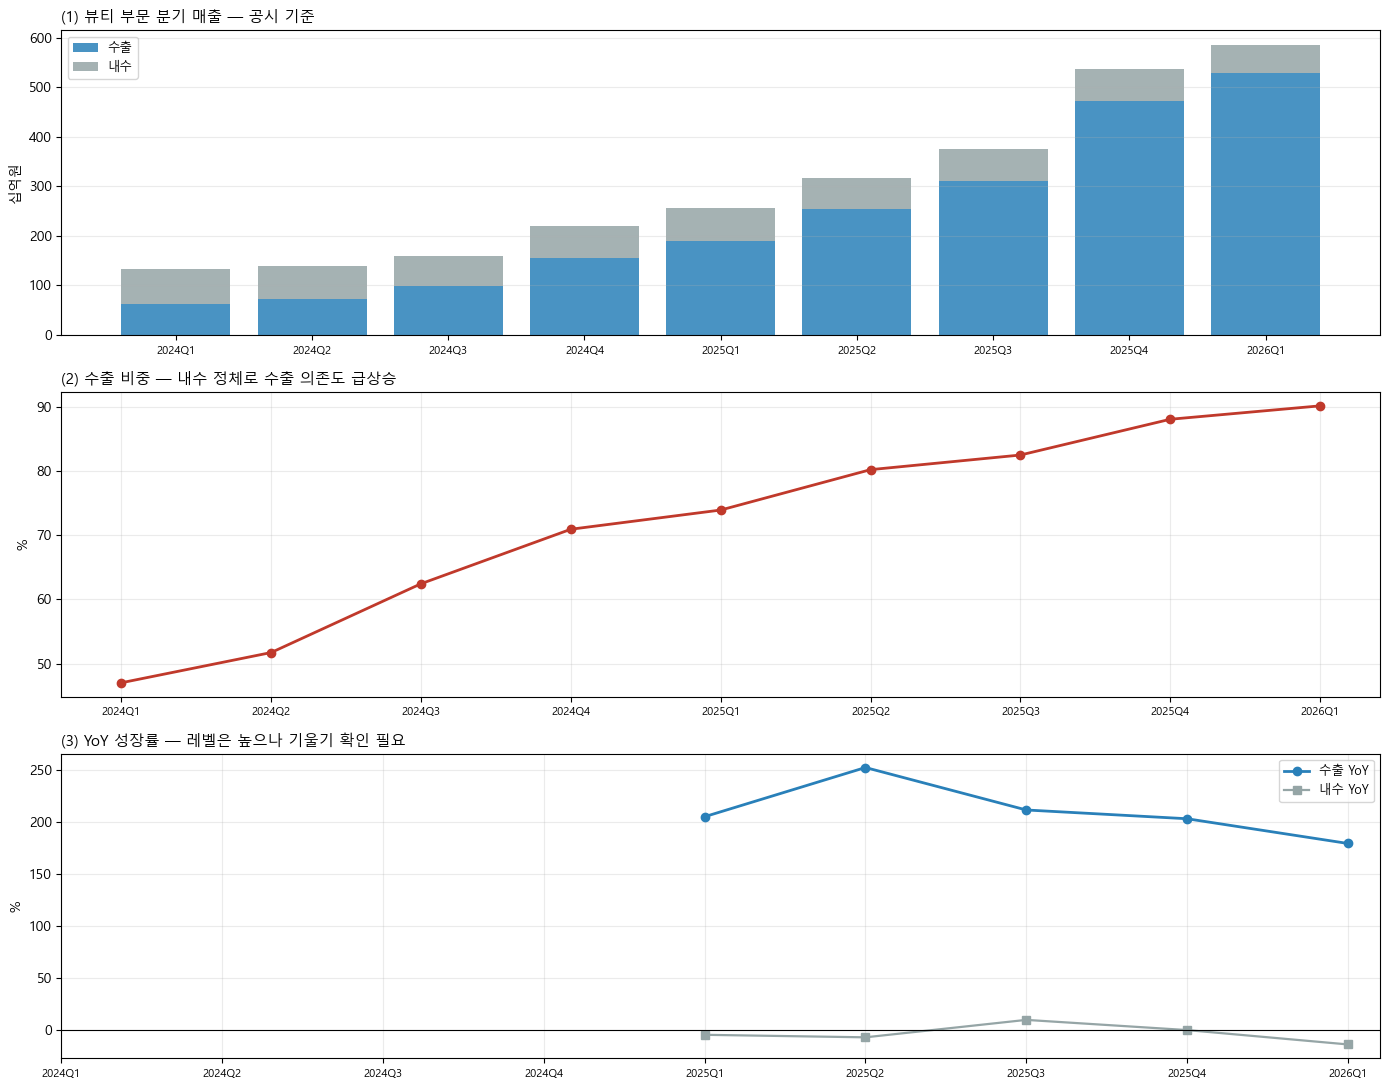

In [13]:
if SHOW_PLOTS:
    import matplotlib
    import matplotlib.pyplot as plt

    for _f in ["Malgun Gothic", "AppleGothic", "NanumGothic", "DejaVu Sans"]:
        try:
            matplotlib.rcParams["font.family"] = _f
            break
        except Exception:
            continue
    matplotlib.rcParams["axes.unicode_minus"] = False

    fig, axes = plt.subplots(3, 1, figsize=(FIG_W, 11))

    x = range(len(rev))
    ax = axes[0]
    ax.bar(x, rev["export"] / 1000, label="수출", color="#2980b9", alpha=0.85)
    ax.bar(x, rev["domestic"] / 1000, bottom=rev["export"] / 1000,
           label="내수", color="#95a5a6", alpha=0.85)
    ax.set_xticks(list(x)); ax.set_xticklabels(rev.index, fontsize=8)
    ax.set_ylabel("십억원")
    ax.set_title("(1) 뷰티 부문 분기 매출 — 공시 기준", fontsize=11, loc="left")
    ax.legend(fontsize=9); ax.grid(alpha=0.25, axis="y")

    ax = axes[1]
    ax.plot(x, rev["export_share"] * 100, marker="o", color="#c0392b", linewidth=2)
    ax.set_xticks(list(x)); ax.set_xticklabels(rev.index, fontsize=8)
    ax.set_ylabel("%")
    ax.set_title("(2) 수출 비중 — 내수 정체로 수출 의존도 급상승", fontsize=11, loc="left")
    ax.grid(alpha=0.25)

    ax = axes[2]
    ax.plot(x, rev["export_yoy"] * 100, marker="o", color="#2980b9",
            linewidth=2, label="수출 YoY")
    ax.plot(x, rev["domestic_yoy"] * 100, marker="s", color="#95a5a6",
            linewidth=1.6, label="내수 YoY")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xticks(list(x)); ax.set_xticklabels(rev.index, fontsize=8)
    ax.set_ylabel("%")
    ax.set_title("(3) YoY 성장률 — 레벨은 높으나 기울기 확인 필요", fontsize=11, loc="left")
    ax.legend(fontsize=9); ax.grid(alpha=0.25)

    plt.tight_layout(); plt.show()


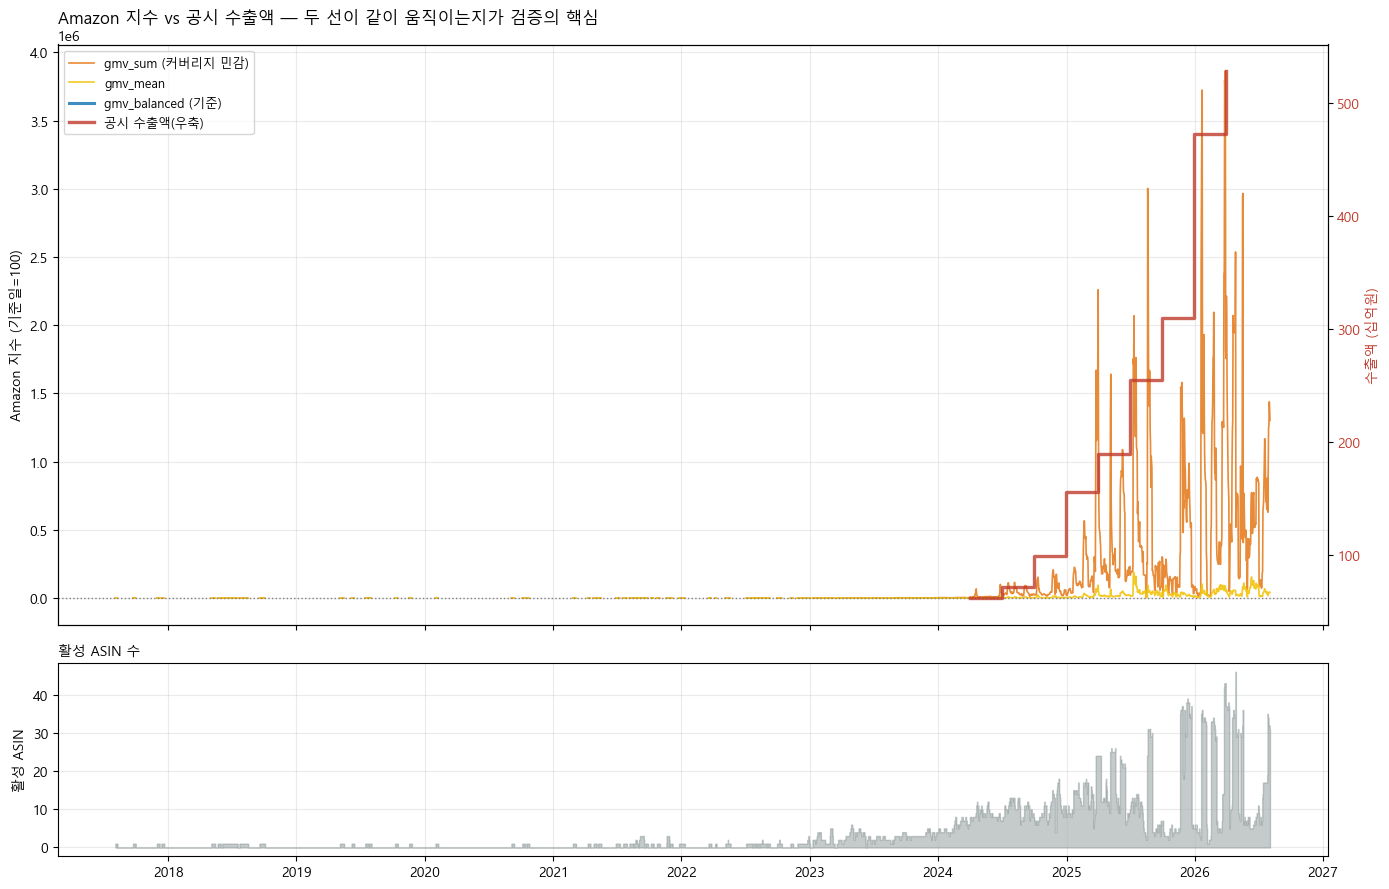

In [14]:
if SHOW_PLOTS and not idx.empty:
    import matplotlib.pyplot as plt

    base_dt = pd.to_datetime(REBASE_DATE) if REBASE_DATE else idx.index.min()

    def rb(s):
        s = s.astype(float)
        a = s.loc[s.index >= base_dt].dropna()
        return s / a.iloc[0] * 100 if len(a) and a.iloc[0] else s

    fig, axes = plt.subplots(2, 1, figsize=(FIG_W, 9), sharex=True,
                             gridspec_kw={"height_ratios": [3, 1]})

    ax = axes[0]
    for col, lbl, c, lw in [("gmv_sum", "gmv_sum (커버리지 민감)", "#e67e22", 1.2),
                            ("gmv_mean", "gmv_mean", "#f1c40f", 1.2),
                            ("gmv_balanced", "gmv_balanced (기준)", "#2980b9", 2.2)]:
        if col in idx.columns:
            ax.plot(idx.index, rb(idx[col]), color=c, linewidth=lw, label=lbl, alpha=0.9)

    # 공시 수출액을 분기 계단으로 겹침
    ax2 = ax.twinx()
    ax2.step(rev["q_end"], rev["export"] / 1000, where="post",
             color="#c0392b", linewidth=2.4, alpha=0.8, label="공시 수출액(우축)")
    ax2.set_ylabel("수출액 (십억원)", color="#c0392b")
    ax2.tick_params(axis="y", labelcolor="#c0392b")

    ax.axhline(100, color="grey", linestyle=":", linewidth=1)
    ax.set_ylabel("Amazon 지수 (기준일=100)")
    ax.set_title("Amazon 지수 vs 공시 수출액 — 두 선이 같이 움직이는지가 검증의 핵심",
                 fontsize=12, loc="left")
    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, fontsize=9, loc="upper left")
    ax.grid(alpha=0.25)

    ax = axes[1]
    ax.fill_between(idx.index, idx["n_active"], color="#7f8c8d", alpha=0.45, step="post")
    ax.set_ylabel("활성 ASIN")
    ax.set_title("활성 ASIN 수", fontsize=10, loc="left")
    ax.grid(alpha=0.25)

    plt.tight_layout(); plt.show()


In [15]:
if SHOW_PLOTS and not idx.empty:
    import matplotlib.pyplot as plt

    iq = idx.resample(RESAMPLE_RULE).mean(numeric_only=True)
    iq.index = pd.DatetimeIndex(iq.index).normalize()
    rq = rev.set_index("q_end")
    chg = 4 if USE_YOY else 1
    key = "export_yoy" if USE_YOY else "export_qoq"

    cmp_df = pd.DataFrame({
        "Amazon(%s)" % PRIMARY_INDEX: iq[PRIMARY_INDEX].pct_change(chg) * 100,
        "공시 수출": rq[key] * 100,
    }).dropna(how="all")

    if len(cmp_df.dropna()) >= 2:
        fig, ax = plt.subplots(figsize=(FIG_W, 5))
        w = 0.38
        xs = np.arange(len(cmp_df))
        ax.bar(xs - w / 2, cmp_df.iloc[:, 0], w, label=cmp_df.columns[0], color="#2980b9")
        ax.bar(xs + w / 2, cmp_df.iloc[:, 1], w, label=cmp_df.columns[1], color="#c0392b")
        ax.axhline(0, color="black", linewidth=0.9)
        ax.set_xticks(xs)
        ax.set_xticklabels([d.strftime("%YQ%q").replace("%q", str((d.month - 1) // 3 + 1))
                            for d in cmp_df.index], fontsize=8)
        ax.set_ylabel("%s (%%)" % ("YoY" if USE_YOY else "QoQ"))
        ax.set_title("방향 대조 — 같은 방향이면 막대가 같은 쪽을 향한다",
                     fontsize=11, loc="left")
        ax.legend(fontsize=9); ax.grid(alpha=0.25, axis="y")
        plt.tight_layout(); plt.show()
    else:
        print("[대조 차트] 공통 관측치 부족")


[대조 차트] 공통 관측치 부족


## 9. 요약

In [16]:
print("=" * 78)
print("APR Amazon 지수 — 공시 수출 앵커 검증 요약")
print("=" * 78)
print("  앵커 : %s" % ANCHOR_SOURCE)
print("         분기 %d개 / YoY 가능 %d개"
      % (len(rev), int(rev["export_yoy"].notna().sum())))
print("         수출 비중 %.1f%% → %.1f%%"
      % (rev["export_share"].iloc[0] * 100, rev["export_share"].iloc[-1] * 100))
if not idx.empty:
    print("  지수 : %d일 / 균형패널 %d ASIN / alpha=%.2f"
          % (len(idx), idx.attrs.get("n_balanced", 0), ALPHA))
if len(verify):
    _m = "가속일치"
    b = verify.dropna(subset=[_m]).sort_values(_m, ascending=False)
    if len(b):
        r = b.iloc[0]
        print("  검증 : 최고 가속일치율 %.0f%% (%s, lag=%d, n=%d)"
              % (r[_m] * 100, r["지수"], r["lag"], r["n_가속"]))
print()
print("  [알려진 한계]")
print("   1. 수출액에는 미국 외 지역이 포함됩니다. 순수 미국 신호가 아닙니다.")
print("   2. Amazon은 미국 매출의 일부입니다 (Ulta·TikTok·DTC 미포함).")
print("   3. 고성장 지속 구간에서는 부호일치율이 무의미합니다.")
print("      가속일치율(성장률 변화 방향)로 판단하십시오.")
print("   4. ALPHA는 자유 파라미터입니다. 민감도 표에서 흔들리면 신뢰 불가.")
print("=" * 78)


APR Amazon 지수 — 공시 수출 앵커 검증 요약
  앵커 : DART 매출실적(뷰티, 연결기준) 누적 차분
         분기 9개 / YoY 가능 5개
         수출 비중 47.0% → 90.2%
  지수 : 3287일 / 균형패널 0 ASIN / alpha=0.70
  검증 : 최고 가속일치율 100% (gmv_sum, lag=1, n=4)

  [알려진 한계]
   1. 수출액에는 미국 외 지역이 포함됩니다. 순수 미국 신호가 아닙니다.
   2. Amazon은 미국 매출의 일부입니다 (Ulta·TikTok·DTC 미포함).
   3. 고성장 지속 구간에서는 부호일치율이 무의미합니다.
      가속일치율(성장률 변화 방향)로 판단하십시오.
   4. ALPHA는 자유 파라미터입니다. 민감도 표에서 흔들리면 신뢰 불가.


---

## 다음 단계

1. **부호 일치율 확인** — 80% 이상이면 신호, 60% 미만이면 이 접근을 접는다.
2. **관세청 연결** — `CUSTOMS_ENABLED = True` 로 산업 대비 알파 산출.
   금액 기준 점유율 분해는 검색량 기반보다 훨씬 단단하다.
3. **분기 누적값 갱신** — 새 보고서가 나오면 `CUM_EXPORT` / `CUM_DOMESTIC` 에
   누적값 한 줄만 추가하면 분기값·YoY·검증이 전부 자동 갱신된다.
4. **다종목 확장** — 실리콘투·삼양식품 등도 같은 구조(공시 수출 + Amazon BSR)로
   확장 가능하다. 종목이 늘면 패널 관측치가 늘어 단일 종목 표본 한계를 우회할 수 있다.

## 앵커를 수출액으로 바꾼 것의 의미

미국 매출은 공시되지 않으므로 **"내 지수가 미국 매출을 맞히는가"는 영원히 답할 수 없다.**
대신 "내 지수가 공시 수출액과 같이 움직이는가"는 답할 수 있다.

답할 수 없는 질문을 붙들고 추정치를 정답 삼는 것보다,
답할 수 있는 질문으로 바꾸고 그 한계를 명시하는 편이 낫다.

---
*V3 · 2026-08 · 짝 노트북: `apr_us_amazon_keepa_v2`, `apr_us_google_trends_v2`*